this notebook analyses the time to beach globally for undrogued drifters

we see that more than 1/5 of all undrogued drifters beach within a year of losing their drogue

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
#import xarray as xr
import os
#import netCDF4 as nc

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import geodatasets

import scipy.stats as sci_stats
from scipy.ndimage import gaussian_filter

from sklearn.preprocessing import MinMaxScaler

/home/openonic/.conda/envs/drifter_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# set plotting text size parameters
plt.rcParams.update({
    'axes.titlesize': 30,
    'axes.labelsize': 24, 
    'xtick.labelsize': 18,  
    'ytick.labelsize': 18,  
    'legend.fontsize': 18, 
    'figure.titlesize': 28})

In [3]:
# load probability of beaching data
os.chdir('/dat1/openonic/Drifters') # directory
beach_undrogued = pd.read_csv('undrogued_beach.csv')
unbeach_undrogued = pd.read_csv('undrogued_unbeach.csv')

In [25]:
unique_ids_unbeach = unbeach_undrogued['id'].unique()
print(len(unique_ids_unbeach))

8377


In [26]:
# calcualte the max time_to_beach value for each unique trajectory
unique_ids_beach = beach_undrogued['id'].unique()
print(len(unique_ids_beach))
max_time_trajs = beach_undrogued.groupby('id')['time_to_beach'].max().reset_index()

3195


Text(0.5, 0, 'years')

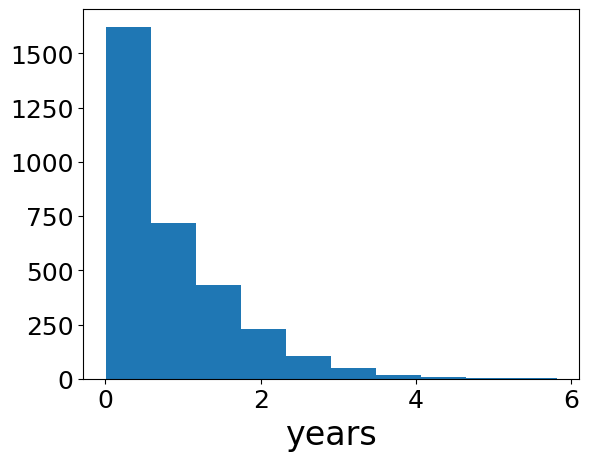

In [27]:
plt.hist(max_time_trajs['time_to_beach']/60/60/24/365)
plt.xlabel('years')

In [28]:
# calculate number that beach within a year
beach_within_yr = max_time_trajs[max_time_trajs['time_to_beach'] <= 31536000]
print(f'drifters that beach within a year of drogue-loss: {len(beach_within_yr)}')

drifters that beach within a year of drogue-loss: 2182


In [29]:
print(f'fraction of total undrogued drifters that beach within a year: {np.round(len(beach_within_yr) / (len(unique_ids_beach) + len(unique_ids_unbeach)),4)}')

fraction of total undrogued drifters that beach within a year: 0.1886


In [30]:
# now let's plot the time to beach heatmap for drifters beaching within a year

In [47]:
os.chdir('/home/openonic/global-drifter-program/new')

In [49]:
def nan_gaussian_filter(values, sigma):
    values = np.asarray(values, dtype=float)

    nan_mask = np.isnan(values)

    if np.all(nan_mask):
        return values

    values_filled = np.where(nan_mask, np.nanmean(values), values)
    filtered = gaussian_filter(values_filled, sigma=sigma)

    filtered[nan_mask] = np.nan
    return filtered


In [50]:
two_year_seconds = 31536000 * 2

n_lons, n_lats = 360, 180
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-90, 90, n_lats + 1)

lon_centers = 0.5 * (lon_bins[:-1] + lon_bins[1:])
lat_centers = 0.5 * (lat_bins[:-1] + lat_bins[1:])

sigma = 0.75

In [51]:
beach_time = beach_undrogued.copy()

valid_mask = beach_time['time_to_beach'] <= two_year_seconds
over_2yr_mask = beach_time['time_to_beach'] > two_year_seconds

time_valid = beach_time.loc[valid_mask].copy()
time_over_2yr = beach_time.loc[over_2yr_mask].copy()

# Convert valid beaching times to months
time_valid['time_to_beach_months'] = (
    time_valid['time_to_beach'] / 60 / 60 / 24 / 30.43
)


In [52]:
mean_months_to_beach, x_edge, y_edge, binnumber = sci_stats.binned_statistic_2d(
    time_valid['lon'],
    time_valid['lat'],
    values=time_valid['time_to_beach_months'],
    statistic='mean',
    bins=[lon_bins, lat_bins]
)

mean_months_to_beach_filtered = nan_gaussian_filter(
    mean_months_to_beach,
    sigma=sigma
)

In [59]:
over_2yr_count, _, _, _ = sci_stats.binned_statistic_2d(
    time_over_2yr['lon'],
    time_over_2yr['lat'],
    values=np.ones(len(time_over_2yr)),
    statistic='sum',
    bins=[lon_bins, lat_bins]
)

# Count all trajectories per grid cell
total_count, _, _, _ = sci_stats.binned_statistic_2d(
    beach_time['lon'],
    beach_time['lat'],
    values=np.ones(len(beach_time)),
    statistic='sum',
    bins=[lon_bins, lat_bins]
)

# Fraction of trajectories in each cell that are >2 years
over_2yr_fraction = over_2yr_count / total_count

# Only mark cells black when at least this fraction are >2 years
over_2yr_fraction_threshold = 0.5

# Also require a minimum number of particles in the cell
min_cell_count = 5

over_2yr_layer = np.where(
    (over_2yr_fraction >= over_2yr_fraction_threshold) &
    (total_count >= min_cell_count),
    1.0,
    np.nan
)

/tmp/ipykernel_224961/1900537153.py:19: RuntimeWarning: invalid value encountered in divide
  over_2yr_fraction = over_2yr_count / total_count


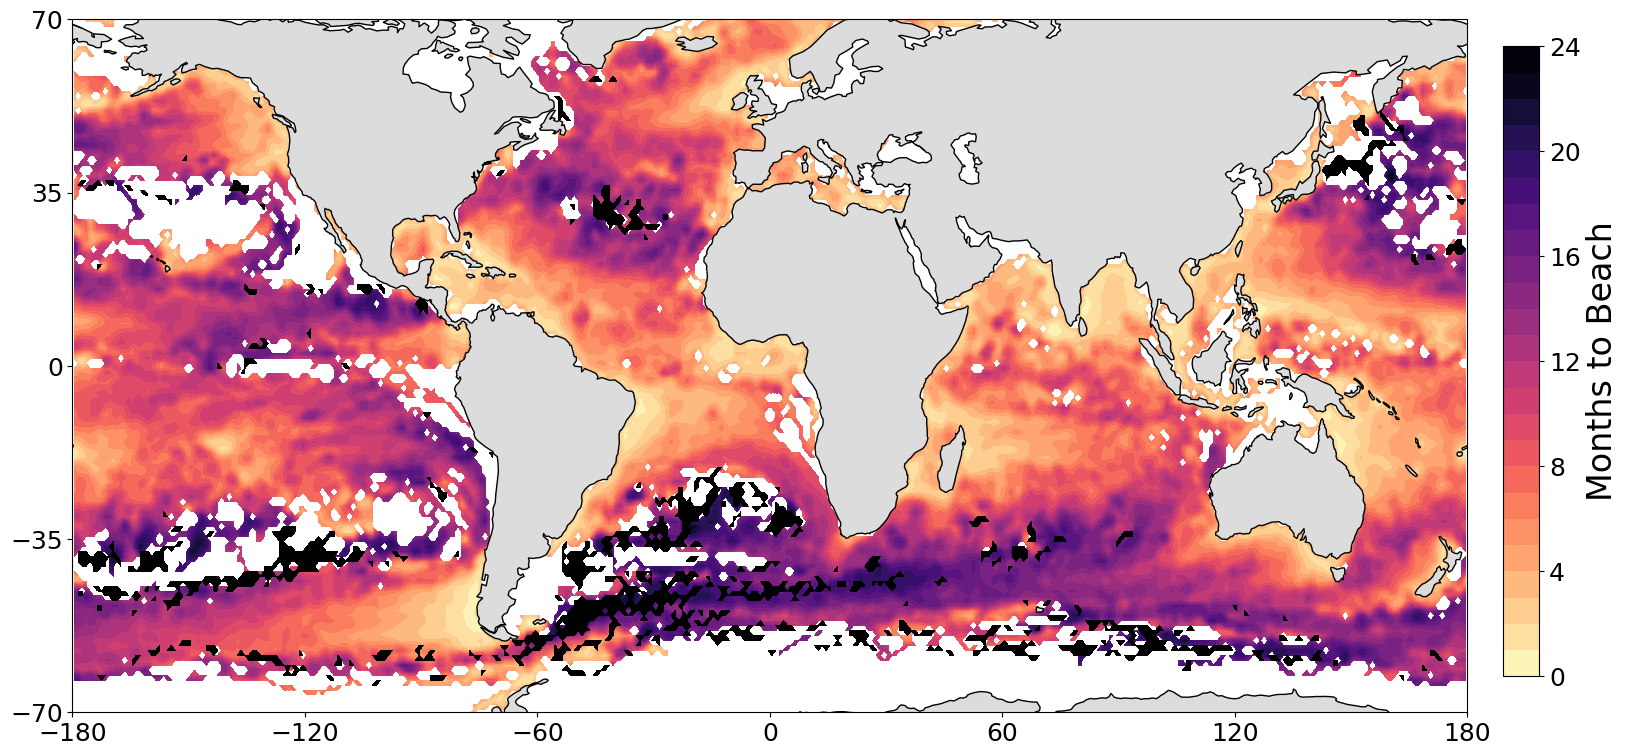

In [60]:
world = gpd.read_file(geodatasets.data.naturalearth.land.path)

fig, ax1 = plt.subplots(
    1,
    1,
    figsize=(18, 9),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)}
)

ax1.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
ax1.set_xticks([-180, -120, -60, 0, 60, 120, 180], crs=ccrs.PlateCarree())
ax1.set_yticks([-70, -35, 0, 35, 70], crs=ccrs.PlateCarree())

# Missing values remain white
cmap = plt.get_cmap('magma_r').copy()
cmap.set_bad('white')

# Main field: valid data only
im1 = ax1.contourf(
    lon_centers,
    lat_centers,
    mean_months_to_beach_filtered.T,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=24,
    levels=np.linspace(0, 24, 25)
)

# Overlay >2-year cells as black
ax1.contourf(
    lon_centers,
    lat_centers,
    over_2yr_layer.T,
    levels=[0.5, 1.5],
    colors=['black'],
    transform=ccrs.PlateCarree()
)

# Land and coastlines
world.plot(ax=ax1, color='gainsboro', edgecolor='none', transform=ccrs.PlateCarree())
ax1.coastlines(color='black')

ax1.set_aspect('auto')

# Colorbar only applies to valid <=2-year data
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im1, cax=cbar_ax, label='Months to Beach')
cbar.set_ticks([0, 4, 8, 12, 16, 20, 24])

plt.show()

In [21]:
# let's look at the vector field of velocity

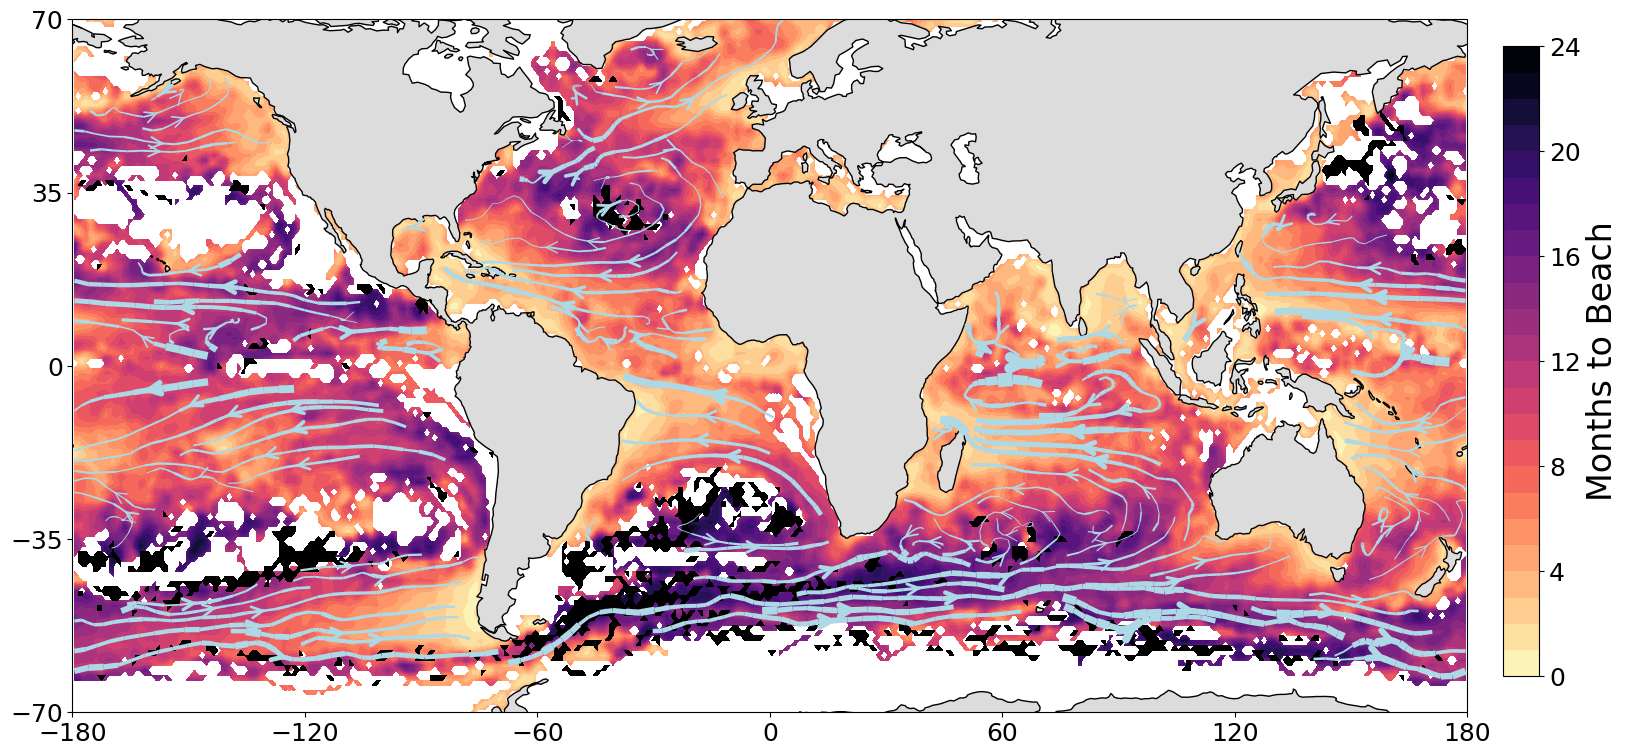

In [61]:
# let's use sci_stats.binned_statistic_2d to bin by lat/lon and count

n_lons, n_lats = 360, 180 # Define the number of grid cells
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-90, 90, n_lats + 1)

yr_vector_stat, x_edge, y_edge, binnumber = sci_stats.binned_statistic_2d(
    undrogued_longs,undrogued_lats,values=(time_yr_month['ve'],time_yr_month['vn']),
    statistic = 'mean', bins = [lon_bins,lat_bins])

world = gpd.read_file(geodatasets.data.naturalearth.land.path)


# visualize 1 year to beach
fig, (ax1) = plt.subplots(1, 1, figsize=(18, 9),
                          subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

ax1.set_xticks([-180, -120, -60, 0, 60, 120, 180])
ax1.set_yticks([-70, -35, 0, 35, 70])


# Missing values remain white
cmap = plt.get_cmap('magma_r').copy()
cmap.set_bad('white')

# Main field: valid data only
im1 = ax1.contourf(
    lon_centers,
    lat_centers,
    mean_months_to_beach_filtered.T,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=24,
    levels=np.linspace(0, 24, 25)
)

# Overlay >2-year cells as black
ax1.contourf(
    lon_centers,
    lat_centers,
    over_2yr_layer.T,
    levels=[0.5, 1.5],
    colors=['black'],
    transform=ccrs.PlateCarree()
)


#ax1.set_title('Probability of Beaching')
#ax1.set_xlabel('Longitude')
#ax1.set_ylabel('Latitude')

# Create a colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cbar_ax, label='Months to Beach')
cbar.set_ticks([0, 4, 8, 12, 16, 20, 24])
im1.set_clim(0, 24)  # This sets the color limits for the ScalarMappable

# Plot undrogued velocity vectors
Lons_2, Lats_2 = np.meshgrid(lons_2, lats_2)
linewidth = 30 * np.sqrt(yr_vector_stat[0].T**2 + yr_vector_stat[1].T**2) / np.sqrt(
    np.nanmax(yr_vector_stat[0].T)**2 + np.nanmax(yr_vector_stat[1].T)**2)
wind_q_global = ax1.streamplot(Lons_2, Lats_2, yr_vector_stat[0].T, yr_vector_stat[1].T, color='lightblue', 
                               linewidth=linewidth, density = 3, arrowsize = 2, arrowstyle = '->')

ax1.coastlines(color = 'black')
world.plot(ax=ax1, color='gainsboro', edgecolor='none')

ax1.set_aspect('auto')
ax1.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())

#plt.savefig('time_to_beach_vectors_poster.png', dpi=600)
# Show the plot
plt.show()

In [63]:
# Separate layer for cells dominated by >2 yr trajectories
two_year_seconds = 31536000 * 2

over_2yr_count, _, _, _ = sci_stats.binned_statistic_2d(
    beach_undrogued.loc[beach_undrogued['time_to_beach'] > two_year_seconds, 'lon'],
    beach_undrogued.loc[beach_undrogued['time_to_beach'] > two_year_seconds, 'lat'],
    values=np.ones((beach_undrogued['time_to_beach'] > two_year_seconds).sum()),
    statistic='sum',
    bins=[lon_bins, lat_bins]
)

total_count, _, _, _ = sci_stats.binned_statistic_2d(
    beach_undrogued['lon'],
    beach_undrogued['lat'],
    values=np.ones(len(beach_undrogued)),
    statistic='sum',
    bins=[lon_bins, lat_bins]
)

over_2yr_fraction = over_2yr_count / total_count

over_2yr_fraction_threshold = 0.75
min_cell_count = 5

over_2yr_layer = np.where(
    (over_2yr_fraction >= over_2yr_fraction_threshold) &
    (total_count >= min_cell_count),
    1.0,
    np.nan
)

/tmp/ipykernel_224961/2862254524.py:20: RuntimeWarning: invalid value encountered in divide
  over_2yr_fraction = over_2yr_count / total_count


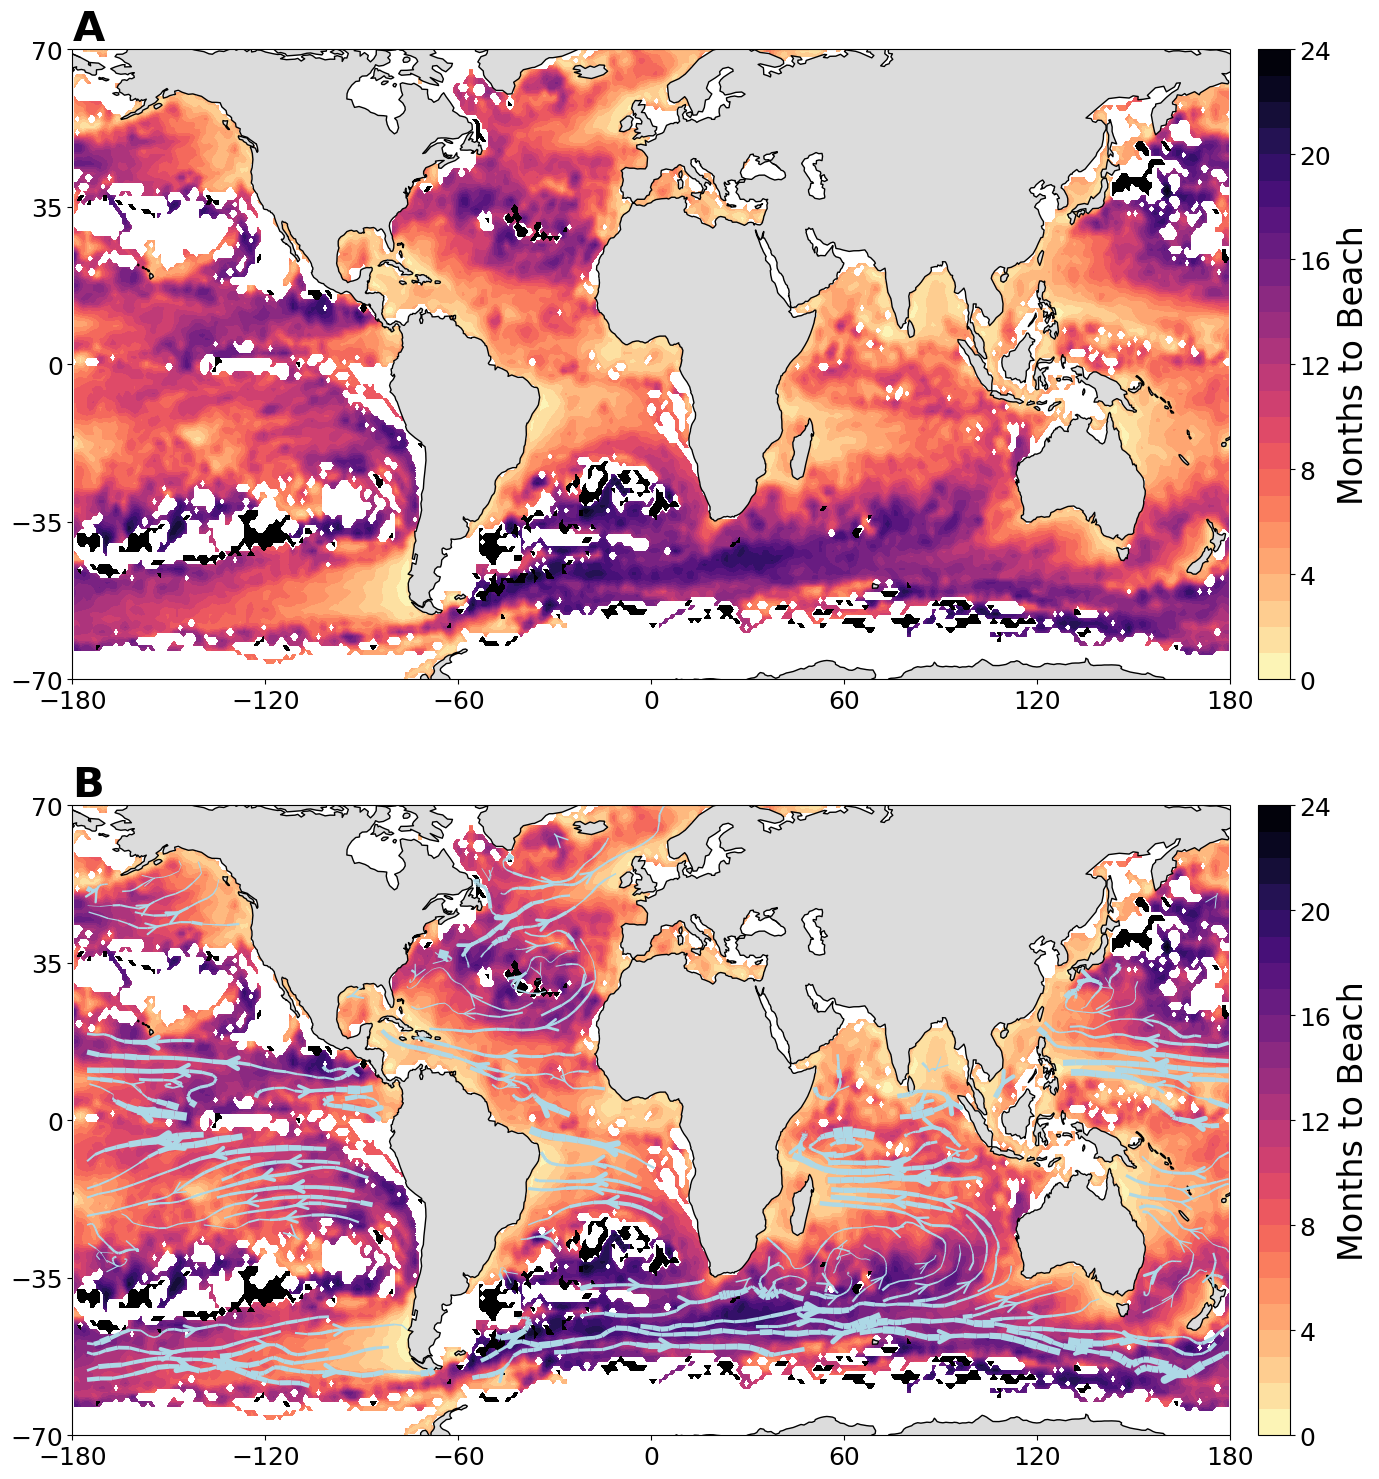

In [65]:
world = gpd.read_file(geodatasets.data.naturalearth.land.path)

# let's use sci_stats.binned_statistic_2d to bin by lat/lon and count
n_lons, n_lats = 360, 180
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-90, 90, n_lats + 1)

yr_vector_stat, x_edge, y_edge, binnumber = sci_stats.binned_statistic_2d(
    undrogued_longs,
    undrogued_lats,
    values=(time_yr_month['ve'], time_yr_month['vn']),
    statistic='mean',
    bins=[lon_bins, lat_bins]
)

# visualize 1 year to beach
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(18, 18),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)}
)

for ax in (ax1, ax2):
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_yticks([-70, -35, 0, 35, 70])

# Missing values remain white
cmap = plt.get_cmap('magma_r').copy()
cmap.set_bad('white')

im1 = ax1.contourf(
    lon_centers,
    lat_centers,
    mean_months_to_beach_filtered.T,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=24,
    levels=np.linspace(0, 24, 25)
)

# Overlay >2-year cells as black
ax1.contourf(
    lon_centers,
    lat_centers,
    over_2yr_layer.T,
    levels=[0.5, 1.5],
    colors=['black'],
    transform=ccrs.PlateCarree()
)

ax1.set_title('A', fontweight='bold', loc='left')

cbar1 = fig.colorbar(
    im1,
    ax=ax1,
    orientation='vertical',
    pad=0.02,
    label='Months to Beach'
)
cbar1.set_ticks([0, 4, 8, 12, 16, 20, 24])

world.plot(ax=ax1, color='gainsboro', edgecolor='none', transform=ccrs.PlateCarree())
ax1.set_aspect('auto')
ax1.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
ax1.coastlines(color='black')


im2 = ax2.contourf(
    lon_centers,
    lat_centers,
    mean_months_to_beach_filtered.T,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=24,
    levels=np.linspace(0, 24, 25)
)

# Overlay >2-year cells as black
ax2.contourf(
    lon_centers,
    lat_centers,
    over_2yr_layer.T,
    levels=[0.5, 1.5],
    colors=['black'],
    transform=ccrs.PlateCarree()
)

ax2.set_title('B', fontweight='bold', loc='left')

cbar2 = fig.colorbar(
    im2,
    ax=ax2,
    orientation='vertical',
    pad=0.02,
    label='Months to Beach'
)
cbar2.set_ticks([0, 4, 8, 12, 16, 20, 24])

# Plot undrogued velocity vectors
Lons_2, Lats_2 = np.meshgrid(lon_centers, lat_centers)

linewidth = 30 * np.sqrt(
    yr_vector_stat[0].T**2 + yr_vector_stat[1].T**2
) / np.sqrt(
    np.nanmax(yr_vector_stat[0].T)**2 + np.nanmax(yr_vector_stat[1].T)**2
)

wind_q_global = ax2.streamplot(
    Lons_2,
    Lats_2,
    yr_vector_stat[0].T,
    yr_vector_stat[1].T,
    color='lightblue',
    linewidth=linewidth,
    density=3,
    arrowsize=2,
    arrowstyle='->'
)

ax2.coastlines(color='black')
world.plot(ax=ax2, color='gainsboro', edgecolor='none', transform=ccrs.PlateCarree())

ax2.set_aspect('auto')
ax2.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())

plt.savefig('figs/time_to_beach.png', dpi=300)
plt.show()